In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Datasets/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
#Select only numeric columns
numerical_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

In [4]:
#3 Handling missing values
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(df[numerical_cols])

In [5]:
#convert back to DF
data_clean = pd.DataFrame(data_imputed, columns=numerical_cols)

In [6]:
#4 Standardize important for PCA
#PCA is affected by feature scale - we scale all features to hace mean
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_clean)

In [7]:
#5 apply PCA
pca = PCA(n_components=7)
data_pca = pca.fit_transform(data_scaled)

In [8]:
#6 check how much information each component keeps
explained_variance = pca.explained_variance_ratio_
cummulative_variance = np.cumsum(explained_variance)

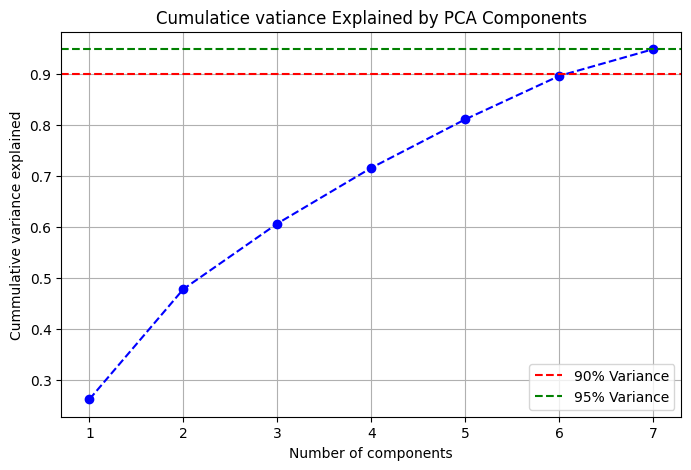

In [9]:
#7 plot cumulatice variannce
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cummulative_variance) + 1), cummulative_variance, marker = 'o', linestyle='--', color = 'b')
plt.title("Cumulatice vatiance Explained by PCA Components")
plt.xlabel('Number of components')
plt.ylabel("Cummulative variance explained")
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Variance')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
#8 Print variance ingo
print("Explained Variance Ratio(each PC shows hwo much info iot captures): ")
print(explained_variance.round(3))

print("cummulative_variance (how much total info is captured: )")
print(cummulative_variance.round(3))

Explained Variance Ratio(each PC shows hwo much info iot captures): 
[0.262 0.216 0.129 0.109 0.095 0.085 0.052]
cummulative_variance (how much total info is captured: )
[0.262 0.478 0.607 0.716 0.812 0.897 0.949]


In [11]:
#9 Find feature contrubution (loadings)
#Loading tell ushow each original featuer contrinutes to each principal component
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=numerical_cols
)

print("Feature loadings (importeance of each feature in each component)")
print(loadings)

Feature loadings (importeance of each feature in each component)
                               PC1       PC2       PC3       PC4       PC5  \
Pregnancies               0.128432  0.593786  0.013087  0.080691  0.475606   
Glucose                   0.393083  0.174029 -0.467923 -0.404329 -0.466328   
BloodPressure             0.360003  0.183892  0.535494  0.055986 -0.327953   
SkinThickness             0.439824 -0.331965  0.237674  0.037976  0.487862   
Insulin                   0.435026 -0.250781 -0.336709 -0.349944  0.346935   
BMI                       0.451941 -0.100960  0.361865  0.053646 -0.253204   
DiabetesPedigreeFunction  0.270611 -0.122069 -0.433189  0.833680 -0.119810   
Age                       0.198027  0.620589 -0.075248  0.071201  0.109290   

                               PC6       PC7  
Pregnancies               0.193598 -0.588790  
Glucose                   0.094162 -0.060153  
BloodPressure            -0.634116 -0.192118  
SkinThickness             0.009589  0.282213

In [12]:
# Add-on; Logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [13]:
#10 Select Optimal Nuber of Components (eg., for 95% variance)
#find the index fo the first component where cumulatice vavriance is >= 0.95
index_of_95 = np.argmax(cummulative_variance >= 0.95)

#np.argmax retuens the index fo the first 'true'. If no true is found it retuns 0 
#we must check if the 95% target was actually reached at that index.
if cummulative_variance[index_of_95] >= 0.95:
    n_opt = index_of_95 + 1
else:
    #If the ratget was not reached, use all available components
    n_opt = len(explained_variance)

print("Optimal number of components to retain 95% variance: {n_opt}")

#use the optimally reduced data for modeling
X_pca_reduced = data_pca[::n_opt]

Optimal number of components to retain 95% variance: {n_opt}


In [14]:

#11. Prepare Data and Model
y = df['Outcome']
# ensure X_pca_reduced uses the first n_opt principal components (not row subsampling)
X_pca_reduced = data_pca[:, :n_opt]
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca_reduced, y, test_size=0.3, random_state=42, stratify=y)

In [15]:
#inetialize and train the Lofistic Regression model
log_reg = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
#12. Predict and Evaluarte
y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.7489
